# NB5 — Build Low-Frequency Model / Prior (REVISED v2)

## Perbaikan dari versi lama
- **BUG FIX `load_npy`/`save_npy`**: Fungsi tidak ada di PipelineIO → diganti `load_npz`/`save_npz`
- **P1 Key naming**: LFM disimpan dengan key `Vp_model`, `Vs_model`, `rho_sat` — konsisten dengan NB6
- **P8**: Range Kriging dinaikkan + pseudo-wells auto-linear antara kedua sumur
- **P12**: TIME extrapolasi SETELAH slice formasi
- **QC plot**: `plot_utils.plot_inversion_section` untuk LFM sections

## Update v3 (Cell 6) — Zone-by-zone horizon-guided LFM
- **Zone-by-zone LFM**: 3 zona stratigrafis: Montara→PV, PV→PR, PR→Nome.
  Tiap zona punya `τ-grid` sendiri sehingga continuity per reflektor internal terjaga.
- **Pseudo-wells per zona**: IDW hanya dari log dalam segmen zona → pseudo-well
  seolah memiliki info sumur nyata di low-freq, dengan TIME variable terikat ke horizon atas zona.
- **Ordinary kriging per zona per τ-step** → un-flatten ke absolute TWT → stitch antar zona.
- **Cosine-taper** di batas Plover_Volcs & Plover_Res untuk transisi halus.
- Fallback otomatis jika horizon internal tidak ada (bagi interval secara linear).

## Cell 1 — Imports + load NB1/NB2/NB3

In [12]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit
from scipy.linalg import solve as linalg_solve

sys.path.insert(0, str(Path.cwd()))
from pipeline_io import PipelineIO
import plot_utils

warnings.filterwarnings("ignore")
np.random.seed(42)

print("=" * 72)
print("  NB5 — BUILD LOW-FREQUENCY MODEL (LFM)")
print("=" * 72)

io_nb1    = PipelineIO(stage="01_well_qc")
CFG       = io_nb1.load_pkl("CFG")
WELL_TOPS = io_nb1.load_pkl("WELL_TOPS")

io_well = PipelineIO(stage="02_well_cond")
WELL_DFRAMES = {}
for wname in CFG["wells"]:
    try:
        WELL_DFRAMES[wname] = io_well.load_df(wname)
        print(f"  v {wname}: {len(WELL_DFRAMES[wname])} samples")
    except FileNotFoundError:
        print(f"  x {wname}: tidak ditemukan di NB2")

# BUG FIX: load_npy -> load_npz dengan key extraction
io_seis        = PipelineIO(stage="03_seismic")
twt_win        = io_seis.load_npz("twt_win")["twt_win"]
trace_axis_inv = io_seis.load_npz("trace_axis_inv")["trace_axis_inv"]
horizons       = io_seis.load_pkl("horizons")
seismic_meta   = io_seis.load_json("seismic_meta")

NTR     = int(seismic_meta["NTR"])
NT_WIN  = int(seismic_meta["NT_WIN"])
DT_SEIS = float(seismic_meta["DT_SEIS"])

WELL_CFGS    = CFG["wells"]
LFM_CFG      = CFG["lfm"]
TOP_HORIZON  = CFG["horizon"]["TOP_HORIZON"]
BOT_HORIZON  = CFG["horizon"]["BOT_HORIZON"]
HORIZON_STYL = CFG["horizon"]["STYLES"]

def _fuzzy_hor(target, hor_dict):
    t = target.lower().strip()
    for k,v in hor_dict.items():
        if k.lower().strip() == t or t in k.lower() or k.lower() in t:
            return v
    return None

top_hz = _fuzzy_hor(TOP_HORIZON, horizons)
bot_hz = _fuzzy_hor(BOT_HORIZON, horizons)
if top_hz is None: top_hz = np.full(NTR, twt_win[0])
if bot_hz is None: bot_hz = np.full(NTR, twt_win[-1])

print(f"\n  NTR={NTR}  NT_WIN={NT_WIN}  DT_SEIS={DT_SEIS*1000:.1f} ms")
print(f"  twt_win  : [{twt_win[0]:.3f}, {twt_win[-1]:.3f}] s")
print(f"  horizons : {list(horizons.keys())}")
print(f"  top_hz ({TOP_HORIZON}): mean={np.nanmean(top_hz):.3f} s")
print(f"  bot_hz ({BOT_HORIZON}): mean={np.nanmean(bot_hz):.3f} s")


  NB5 — BUILD LOW-FREQUENCY MODEL (LFM)
  v Poseidon-1: 977 samples
  v Boreas-1: 1068 samples

  NTR=895  NT_WIN=114  DT_SEIS=4.0 ms
  twt_win  : [3.000, 3.452] s
  horizons : ['Montara', 'Nome', 'Plover_Reservoir', 'Plover_Volcanics']
  top_hz (Montara): mean=3.114 s
  bot_hz (Nome): mean=3.340 s


## Cell 2 — Helper functions

In [13]:
def lookup_top(name, tops_dict):
    if name is None or not tops_dict: return None
    t = str(name).strip().lower()
    for k, v in tops_dict.items():
        if str(k).strip().lower() == t: return float(v)
    return None

def despike_log(x, threshold=7.5, window=11):
    x_f = median_filter(np.asarray(x, float), size=window, mode="nearest")
    mad = np.median(np.abs(x - x_f))
    if mad < 1e-10: return np.asarray(x, float).copy()
    out = np.asarray(x, float).copy()
    spike = np.abs(x - x_f) > threshold * mad
    out[spike] = x_f[spike]
    return out

def estimate_twt_from_depth(df):
    vp_col = "VP" if "VP" in df.columns else "VP"
    vp  = df[vp_col].fillna(df[vp_col].median()).values if vp_col in df.columns else np.full(len(df), 3000.)
    md  = df["DEPTH"].values
    dz  = np.gradient(md)
    dt  = 2.0 * dz / np.maximum(vp, 1.0)
    return np.cumsum(dt)

def butter_lowpass(x, fs, fcut, order=4):
    b, a = butter(order, fcut / (fs / 2), btype="low")
    return filtfilt(b, a, x, method="gust")

def resample_well_to_twt(df, twt_grid, log_names):
    if "TIME" not in df.columns:
        raise ValueError("Kolom TIME tidak ditemukan")
    df_v = df[df["TIME"].notna()].sort_values("TIME").reset_index(drop=True)
    t    = df_v["TIME"].values
    if t.max() >= 100: t = t / 1000.0
    out = {"TIME": twt_grid}
    for log in log_names:
        if log not in df_v.columns:
            out[log] = np.full(len(twt_grid), np.nan); continue
        v  = df_v[log].values
        fi = interp1d(t, v, bounds_error=False, fill_value=(v[0], v[-1]))
        out[log] = fi(twt_grid)
    eps = (twt_grid[1]-twt_grid[0]) * 0.5
    out["VALID"] = ((twt_grid >= t.min()-eps) & (twt_grid <= t.max()+eps)).astype(int)
    return pd.DataFrame(out)

def assign_well_to_trace(well_name):
    abs_trace = WELL_CFGS.get(well_name, {}).get("trace_idx")
    if abs_trace is None: return NTR // 2
    if abs_trace < trace_axis_inv[0]: return 0
    if abs_trace > trace_axis_inv[-1]: return NTR - 1
    return int(np.argmin(np.abs(trace_axis_inv - abs_trace)))

print("[Cell 2] Helpers ready")


[Cell 2] Helpers ready


## Cell 3 — Well conditioning 2D (TWT domain)


  WELL CONDITIONING 2D (TWT domain)

------------------------------------------------------------
  Poseidon-1
------------------------------------------------------------
  Cut DEPTH >= 4628.7 m -> 977 samples
  Done: 977 samples  TIME=[3.056, 3.298] s

------------------------------------------------------------
  Boreas-1
------------------------------------------------------------
  Cut DEPTH >= 4675.4 m -> 1068 samples
  Done: 1035 samples  TIME=[3.152, 3.368] s


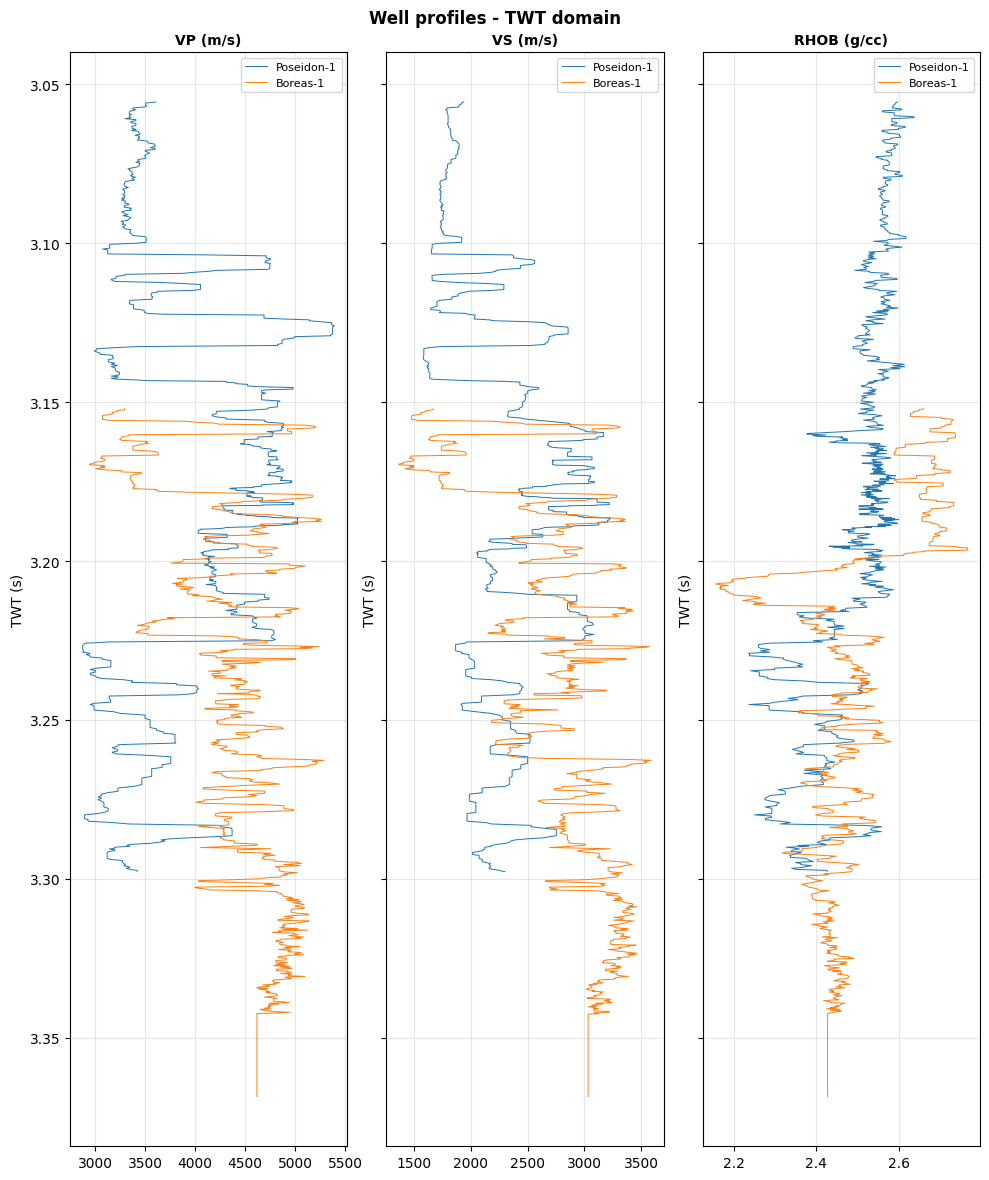

In [14]:
print("\n" + "=" * 72)
print("  WELL CONDITIONING 2D (TWT domain)")
print("=" * 72)

CUT_FORM    = CFG["well_cond_2d"]["cutoff_formation"]
DESPK_CFG   = CFG["well_cond_2d"]["despike"]
EL_LOGS     = ["VP","VS","RHOB"]
PT_LOGS     = ["PHIE","VSH","SW"]

WELLS_LITHO = {}

for wname, df_raw in WELL_DFRAMES.items():
    print("\n" + "-"*60 + f"\n  {wname}\n" + "-"*60)
    df = df_raw.copy()

    # TIME column
    for tcol in ["TIME_TWT","TWT","TWO_WAY_TIME","TIME"]:
        if tcol in df.columns and tcol != "TIME":
            df["TIME"] = df[tcol]; break

    if "TIME" not in df.columns:
        print(f"  TIME tidak ada - estimasi dari Vp integrasi")
        df["TIME"] = estimate_twt_from_depth(df)

    if "TIME" in df.columns and df["TIME"].dropna().max() >= 100:
        df["TIME"] = df["TIME"] / 1000.0

    # P12: cut SEBELUM TIME extrapolasi
    cut_z = lookup_top(CUT_FORM, WELL_TOPS.get(wname, {}))
    if cut_z is not None and "DEPTH" in df.columns:
        df = df[df["DEPTH"] >= cut_z].copy().reset_index(drop=True)
        print(f"  Cut DEPTH >= {cut_z:.1f} m -> {len(df)} samples")

    # TIME extrapolasi (setelah cut - array terbatas)
    if "TIME" in df.columns and df["TIME"].isna().any():
        t_v = df["TIME"].values.copy(); d_v = df["DEPTH"].values
        vp_col = "VP" if "VP" in df.columns else "VP"
        vp_v = df[vp_col].fillna(df[vp_col].median() if vp_col in df.columns else 3000.).values
        valid_idx = np.where(np.isfinite(t_v))[0]
        if len(valid_idx):
            t_last = t_v[valid_idx[-1]]
            for i in range(valid_idx[-1]+1, len(t_v)):
                dz = abs(d_v[i] - d_v[i-1])
                vp_m = max((vp_v[i]+vp_v[i-1])/2., 1.)
                t_last = t_last + 2.*dz/vp_m; t_v[i] = t_last
            df["TIME"] = t_v
            n_ex = len(df) - (valid_idx[-1]+1)
            print(f"  TIME extrapolated {n_ex} samples")

    # Despike
    for log in DESPK_CFG.get("logs", []):
        if log in df.columns:
            df[log] = despike_log(df[log].values, DESPK_CFG["threshold"], DESPK_CFG["window"])

    # Drop where elastic NaN
    avail_el = [c for c in EL_LOGS if c in df.columns]
    if avail_el:
        df = df.dropna(subset=avail_el).reset_index(drop=True)
    df = df[df["TIME"].notna()].reset_index(drop=True)
    WELLS_LITHO[wname] = df
    print(f"  Done: {len(df)} samples  TIME=[{df['TIME'].min():.3f}, {df['TIME'].max():.3f}] s")

# QC profile
fig, axes = plt.subplots(1, 3, figsize=(10, 12), sharey=True)
for wname, df in WELLS_LITHO.items():
    t = df["TIME"].values
    for ax, col in zip(axes, ["VP","VS","RHOB"]):
        if col in df.columns:
            ax.plot(df[col], t, label=wname, lw=0.7)
for ax, t_lbl in zip(axes, ["VP (m/s)","VS (m/s)","RHOB (g/cc)"]):
    ax.set_title(t_lbl, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.invert_yaxis()
    ax.set_ylabel("TWT (s)")
plt.suptitle("Well profiles - TWT domain", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## Cell 4 — Resample wells to TWT + lowpass filter

In [15]:
print("\n" + "=" * 72)
print("  RESAMPLE + LOW-FREQUENCY FILTER")
print("=" * 72)

fs   = 1.0 / DT_SEIS
fcut = float(LFM_CFG["filter_freq_hz"])
print(f"  seismic fs={fs:.0f} Hz  LFM cutoff={fcut:.0f} Hz")

EL_MAP = {"VP":"VP","VS":"VP","RHOB":"RHOB"}
EL_LOGS = [c for c in ["VP","VS","RHOB"]
           if any(c in df.columns for df in WELLS_LITHO.values())]
PT_LOGS = [c for c in ["PHIE","VSH","SW"]
           if any(c in df.columns for df in WELLS_LITHO.values())]
ALL_LOGS = EL_LOGS + PT_LOGS

well_twt       = {}
well_trace_idx = {}

for wname, df in WELLS_LITHO.items():
    print(f"\n  {wname}:")
    wt = resample_well_to_twt(df, twt_win, ALL_LOGS)
    for log in ALL_LOGS:
        if log not in wt.columns or wt[log].isna().all(): continue
        raw  = wt[log].fillna(wt[log].median()).values
        filt = butter_lowpass(raw, fs, fcut)
        if "PHIE" in log: filt = np.clip(filt, 0.001, 0.45)
        elif "VSH" in log or "SW" in log: filt = np.clip(filt, 0.001, 1.0)
        wt[f"{log}_LF"] = filt
    well_twt[wname]       = wt
    well_trace_idx[wname] = assign_well_to_trace(wname)
    print(f"    trace_idx={well_trace_idx[wname]}  valid={int(wt['VALID'].sum())}/{NT_WIN}")

print(f"\n  EL_LOGS  : {EL_LOGS}")
print(f"  PT_LOGS  : {PT_LOGS}")



  RESAMPLE + LOW-FREQUENCY FILTER
  seismic fs=250 Hz  LFM cutoff=20 Hz

  Poseidon-1:
    trace_idx=414  valid=61/114

  Boreas-1:
    trace_idx=602  valid=55/114

  EL_LOGS  : ['VP', 'VS', 'RHOB']
  PT_LOGS  : ['PHIE', 'VSH', 'SW']


## Cell 5 — Kriging engine (variogram + ordinary kriging)

In [16]:
# Variogram model functions
def _vario_spherical(h, nugget, sill, rng):
    h = np.asarray(h,float); hr = h/max(rng,1e-9)
    return np.where(h==0,0., np.where(h<rng, nugget+sill*(1.5*hr-0.5*hr**3), nugget+sill))

def _vario_exponential(h, nugget, sill, rng):
    h = np.asarray(h,float)
    return np.where(h==0,0., nugget+sill*(1.-np.exp(-h/max(rng,1e-9))))

def _vario_gaussian(h, nugget, sill, rng):
    h = np.asarray(h,float)
    return np.where(h==0,0., nugget+sill*(1.-np.exp(-(h/max(rng,1e-9))**2)))

VARIO_FUNCS = {"spherical":_vario_spherical, "exponential":_vario_exponential,
               "gaussian":_vario_gaussian}

KRIGING_CFG = {"variogram_model":"gaussian","nugget":0.0,"sill":None,
               "range_traces":None,"fit_variogram":True,"n_lags":20,
               **CFG["lfm"].get("kriging", {})}
print("  Kriging config:")

for k,v in KRIGING_CFG.items(): print(f"    {k:<22s} = {v}")

SMOOTH_CFG = {
    "enable"           : True,
    "boundary_blend_ms": float(LFM_CFG.get("boundary_blend_ms", 20.0)),  # lebar taper per sisi (ms)
    "face_weight"      : float(LFM_CFG.get("boundary_face_weight", 0.85)), # 0=lemah, 1=hard-pin
    "taper_power"      : float(LFM_CFG.get("boundary_taper_power",  2.0)), # 1=linier, 2=kuadratik
}
print(f"  Boundary smooth : blend={SMOOTH_CFG['boundary_blend_ms']:.0f} ms  "
      f"weight={SMOOTH_CFG['face_weight']:.2f}  power={SMOOTH_CFG['taper_power']:.1f}")

def build_arc_length(ref_hz):
    ntr = len(ref_hz); hz_rng = np.nanmax(ref_hz)-np.nanmin(ref_hz)
    dip_scale = ntr / (hz_rng + 1e-10)
    dhz = np.diff(ref_hz)
    ds  = np.sqrt(1.0 + (dhz * dip_scale)**2)
    return np.concatenate([[0.0], np.cumsum(ds)])

def geodesic_dist(idx_a, idx_b, arc):
    return np.abs(arc[int(idx_a)] - arc[int(idx_b)])

def fit_variogram(h, g, model="spherical", nugget=0.0):
    if len(h) < 3: return nugget, float(np.nanvar(g)), float(np.nanmax(h)*0.5)
    sill_i = float(np.nanmax(g)) ; rng_i = float(np.nanmax(h)*0.5)
    vfunc  = VARIO_FUNCS[model]
    try:
        popt, _ = curve_fit(lambda h,s,r: vfunc(h,nugget,s,r), h, g,
                            p0=[sill_i,rng_i],
                            bounds=([0,1e-3],[sill_i*5,np.nanmax(h)*2]), maxfev=3000)
        return nugget, float(popt[0]), float(popt[1])
    except Exception:
        return nugget, sill_i, rng_i

def ordinary_kriging_1d(well_xs, well_vals, query_xs, arc, nugget, sill, rng_, model="spherical"):
    vfunc = VARIO_FUNCS.get(model, _vario_spherical)
    nW = len(well_xs); nQ = len(query_xs)
    K = np.zeros((nW+1, nW+1))
    for i in range(nW):
        for j in range(nW):
            h = geodesic_dist(well_xs[i], well_xs[j], arc)
            K[i,j] = (nugget+sill) - vfunc(h, nugget, sill, rng_)
    K[:nW,nW]=1.; K[nW,:nW]=1.; K[nW,nW]=0.
    pred = np.zeros(nQ)
    for qi,qx in enumerate(query_xs):
        k_q = np.zeros(nW+1)
        for i in range(nW):
            h = geodesic_dist(well_xs[i], qx, arc)
            k_q[i] = (nugget+sill) - vfunc(h, nugget, sill, rng_)
        k_q[nW] = 1.
        try:
            lam = linalg_solve(K + 1e-8*np.eye(nW+1), k_q)
            pred[qi] = np.dot(lam[:nW], well_vals)
        except np.linalg.LinAlgError:
            pred[qi] = np.nanmean(well_vals)
    return pred

print("\n  Kriging engine ready")


  Kriging config:
    variogram_model        = gaussian
    nugget                 = 0.0
    sill                   = None
    range_traces           = None
    fit_variogram          = True
    n_lags                 = 20
  Boundary smooth : blend=20 ms  weight=0.85  power=2.0

  Kriging engine ready


## Cell 6 — Zone-by-Zone Horizon-Guided LFM (v3)

**Perubahan dari v2:**
- Rentang inversi (Montara→Nome) dibagi **3 zona stratigrafis**:
  `Z1: Montara→Plover_Volcanics`, `Z2: Plover_Volcanics→Plover_Reservoir`,
  `Z3: Plover_Reservoir→Nome`.
- Tiap zona punya **τ-grid sendiri**: `τ = twt − top_hz_zona` sehingga
  continuity per horizon benar-benar ditangkap.
- **Pseudo-wells dibangun per zona**: IDW hanya menggunakan log dalam
  segmen zona tersebut → pseudo-well seolah punya info sumur nyata
  namun dalam frekuensi rendah, dengan TIME variable terikat horizon.
- **Kriging ordinary 1-D per zona per τ-step** → cube τ → un-flatten
  ke absolute TWT → stitch antar zona dengan cosine-taper.
- Fallback otomatis: jika horizon internal tidak tersedia, dibagi linear.

In [17]:
print("\n" + "=" * 72)
print("  Cell 6 v3-GPU — ZONE-BY-ZONE HORIZON-GUIDED LFM (CuPy Accelerated)")
print("=" * 72)
print("  Montara->PV  |  PV->PR  |  PR->Nome")
print("=" * 72)

import time

# ---------------------------------------------------------------------------
# 0a.  CuPy GPU Setup — dengan graceful fallback ke CPU NumPy
# ---------------------------------------------------------------------------
try:
    import cupy as cp
    import cupy.linalg as cpla
    _test = cp.array([1.0])          # smoke-test: pastikan CUDA benar-benar aktif
    _GPU  = True
    _mem  = cp.cuda.Device().mem_info
    print(f"\n  [GPU] CuPy ENABLED  |  "
          f"Free VRAM : {_mem[0]/1e9:.2f} GB  /  "
          f"Total VRAM: {_mem[1]/1e9:.2f} GB")
    del _test
except Exception as _e:
    _GPU = False
    print(f"\n  [GPU] CuPy tidak tersedia ({_e})\n"
          f"        → fallback CPU NumPy (hasil identik, lebih lambat)")

# ---------------------------------------------------------------------------
# 0b.  Common well + kriging setup  (identik dengan versi asli)
# ---------------------------------------------------------------------------
well_names      = list(well_twt.keys())
trace_idxs      = np.array([well_trace_idx[w] for w in well_names])
inter_well_dist = (float(np.max(trace_idxs) - np.min(trace_idxs))
                   if len(trace_idxs) >= 2 else float(NTR))

range_factor = float(LFM_CFG.get("range_traces_factor", 0.50))
range_forced = max(int(inter_well_dist * range_factor), 20)
KRIGING_CFG["range_traces"] = range_forced

_n_legacy      = int(LFM_CFG.get("n_pseudo_wells", 10))
N_PSEUDO_INNER = int(LFM_CFG.get("n_pseudo_inner", _n_legacy))
N_PSEUDO_LEFT  = int(LFM_CFG.get("n_pseudo_left",  6))
N_PSEUDO_RIGHT = int(LFM_CFG.get("n_pseudo_right", 6))
N_PSEUDO       = N_PSEUDO_LEFT + N_PSEUDO_INNER + N_PSEUDO_RIGHT

BLEND_MS = float(LFM_CFG.get("zone_blend_ms", 5.0))

ARC_REF = build_arc_length(top_hz)
EL_MAP  = {"VP": "VP", "VS": "VS", "RHOB": "RHOB"}

print(f"\n  inter-well dist : {inter_well_dist:.0f} traces")
print(f"  range_traces    : {range_forced} traces  ({range_factor*100:.0f}% x inter-well)")
print(f"  pseudo-wells    : LEFT={N_PSEUDO_LEFT}  INNER={N_PSEUDO_INNER}  "
      f"RIGHT={N_PSEUDO_RIGHT}  (total={N_PSEUDO})")
print(f"  zone blend      : {BLEND_MS:.1f} ms cosine taper di batas zona")

# ---------------------------------------------------------------------------
# 1.  Load zone horizons & build ZONES list
# ---------------------------------------------------------------------------
_ZONE_HORIZON_NAMES = ["Montara", "Plover_Volcanics", "Plover_Reservoir", "Nome"]
_ZONE_DEFS = [
    ("Montara",          "Plover_Volcanics",  "Z1_Montara_PV"),
    ("Plover_Volcanics", "Plover_Reservoir",  "Z2_PV_PR"),
    ("Plover_Reservoir", "Nome",              "Z3_PR_Nome"),
]

_loaded_hz = {}
print("\n  Loading zone horizons:")
for hname in _ZONE_HORIZON_NAMES:
    arr = _fuzzy_hor(hname, horizons)
    if arr is not None:
        _loaded_hz[hname] = np.asarray(arr, dtype=float)
        print(f"    v {hname:25s}: mean = {np.nanmean(arr)*1000:.1f} ms")
    else:
        print(f"    ! {hname:25s}: tidak ditemukan -> fallback linier")

def _make_hz_fallback(frac):
    return top_hz + frac * (bot_hz - top_hz)

if "Montara"          not in _loaded_hz: _loaded_hz["Montara"]          = top_hz.copy()
if "Nome"             not in _loaded_hz: _loaded_hz["Nome"]             = bot_hz.copy()
if "Plover_Volcanics" not in _loaded_hz: _loaded_hz["Plover_Volcanics"] = _make_hz_fallback(1/3)
if "Plover_Reservoir" not in _loaded_hz: _loaded_hz["Plover_Reservoir"] = _make_hz_fallback(2/3)

ZONES = []
print("\n  Zone geometry:")
for top_name, bot_name, label in _ZONE_DEFS:
    top_arr  = _loaded_hz[top_name]
    bot_arr  = _loaded_hz[bot_name]
    thick    = bot_arr - top_arr
    valid_th = thick[thick > 1e-5]
    if valid_th.size == 0:
        print(f"    ! {label}: ketebalan = 0 -> skip")
        continue
    mean_thick = float(np.nanmean(valid_th))
    NT_Z       = max(2, int(np.round(mean_thick / DT_SEIS)) + 1)
    tau_grid   = np.linspace(0.0, mean_thick, NT_Z)
    ZONES.append(dict(label=label,
                      top_name=top_name, bot_name=bot_name,
                      top_hz=top_arr, bot_hz=bot_arr,
                      mean_thick=mean_thick, tau_grid=tau_grid, NT_Z=NT_Z))
    print(f"    {label:22s}: thick_mean={mean_thick*1000:.1f} ms  NT_Z={NT_Z}")

print(f"\n  Total zona aktif: {len(ZONES)}")

# ---------------------------------------------------------------------------
# 2.  Pseudo-well positions — sama di semua zona
# ---------------------------------------------------------------------------
def _get_pseudo_xs():
    t_min_w = int(min(trace_idxs))
    t_max_w = int(max(trace_idxs))
    parts   = []
    if t_min_w > 1 and N_PSEUDO_LEFT > 0:
        parts.append(np.linspace(0, t_min_w, N_PSEUDO_LEFT+2)[1:-1].astype(int))
    if len(well_names) >= 2 and N_PSEUDO_INNER > 0:
        parts.append(np.linspace(t_min_w, t_max_w, N_PSEUDO_INNER+2)[1:-1].astype(int))
    if t_max_w < NTR-2 and N_PSEUDO_RIGHT > 0:
        parts.append(np.linspace(t_max_w, NTR-1, N_PSEUDO_RIGHT+2)[1:-1].astype(int))
    return np.concatenate(parts).astype(int) if parts else np.array([], dtype=int)

PSEUDO_XS = _get_pseudo_xs()
print(f"\n  Pseudo-well positions ({len(PSEUDO_XS)} total): {PSEUDO_XS.tolist()}")

# ---------------------------------------------------------------------------
# 3.  GPU Helpers
# ---------------------------------------------------------------------------

def _vario_gpu(h, nug, sill, rng, model, xp_mod):
    """
    Hitung nilai variogram γ(h).
    Kompatibel dengan NumPy (CPU) maupun CuPy (GPU) — pilih via xp_mod.
    """
    rng   = max(float(rng), 1e-9)
    psill = float(sill) - float(nug)          # partial sill
    nug_f = float(nug)

    if model == "spherical":
        hr    = h / rng
        g_in  = nug_f + psill * (1.5 * hr - 0.5 * hr**3)
        g_out = xp_mod.full_like(h, nug_f + psill)
        return xp_mod.where(hr <= 1.0, g_in, g_out)
    elif model == "exponential":
        return nug_f + psill * (1.0 - xp_mod.exp(-3.0 * h / rng))
    elif model == "gaussian":
        return nug_f + psill * (1.0 - xp_mod.exp(-3.0 * (h / rng)**2))
    else:                                       # fallback: spherical
        hr    = h / rng
        g_in  = nug_f + psill * (1.5 * hr - 0.5 * hr**3)
        g_out = xp_mod.full_like(h, nug_f + psill)
        return xp_mod.where(hr <= 1.0, g_in, g_out)


def _ok_batch_gpu(xs_data, vals_mat, query_xs, arc_ref, nug, sill, rng, model):
    """
    Ordinary Kriging BATCHED untuk multiple right-hand side (tau-steps).

    Keunggulan vs loop asli
    -----------------------
    Versi asli  : NT_Z kali solve sistem (nD+1)×(nD+1) secara serial di CPU
    Versi ini   : bangun K sekali → solve SATU kali untuk semua nQ query
                  → hasilkan prediksi semua NT_Z sekaligus via matmul GPU

    Kompleksitas:
      Lama  : O(NT_Z × [nD³ + nQ·nD])
      Baru  : O(nD³ + nD²·nQ + nQ·nD·NT_Z)   ← ~NT_Z× lebih sedikit solve

    Parameters
    ----------
    xs_data  : ndarray (nD,)       trace-index titik data
    vals_mat : ndarray (nD, nRHS)  nilai per titik data per tau-step (NaN sudah diisi)
    query_xs : ndarray (nQ,)       trace-index query (seluruh penampang)
    arc_ref  : ndarray (NTR,)      lookup arc-length (sama seperti ordinary_kriging_1d)
    nug, sill, rng : float         parameter variogram
    model    : str                 'spherical' / 'exponential' / 'gaussian'

    Returns
    -------
    pred : ndarray (nQ, nRHS) float32
    """
    xp   = cp if _GPU else np
    nD   = len(xs_data)
    nQ   = len(query_xs)
    nRHS = vals_mat.shape[1]

    # Edge case: hanya 1 titik data → broadcast konstan
    if nD == 1:
        return np.tile(vals_mat[0:1, :].astype(np.float32), (nQ, 1))

    # Arc-length mapping (CPU, array kecil → tidak perlu GPU)
    NTR_arc = len(arc_ref)
    arc_d   = arc_ref[np.clip(xs_data.astype(int), 0, NTR_arc - 1)]
    arc_q   = arc_ref[np.clip(query_xs.astype(int), 0, NTR_arc - 1)]

    # Transfer ke device (GPU atau tetap CPU jika _GPU=False)
    arc_d_g  = xp.array(arc_d,    dtype=xp.float64)   # (nD,)
    arc_q_g  = xp.array(arc_q,    dtype=xp.float64)   # (nQ,)
    vals_g   = xp.array(vals_mat, dtype=xp.float64)   # (nD, nRHS)

    # ── Variogram matrix data–data: Γ_DD (nD × nD) ──────────────────────
    h_dd = xp.abs(arc_d_g[:, None] - arc_d_g[None, :])   # (nD, nD)
    G_dd = _vario_gpu(h_dd, nug, sill, rng, model, xp)

    # ── Augmented ordinary kriging system (nD+1 × nD+1) ─────────────────
    #   [ Γ_DD | 1 ] [w ]   [ γ(x_q) ]
    #   [  1ᵀ  | 0 ] [μ ] = [   1    ]
    K_aug           = xp.zeros((nD + 1, nD + 1), dtype=xp.float64)
    K_aug[:nD, :nD] = G_dd
    K_aug[:nD,  nD] = 1.0
    K_aug[ nD, :nD] = 1.0
    # K_aug[nD, nD] = 0  (Lagrange multiplier condition)

    # Regularisasi kecil untuk stabilitas numerik
    reg = max(float(nug) * 0.01, 1e-10) * max(float(sill), 1e-10)
    K_aug[:nD, :nD] += xp.eye(nD, dtype=xp.float64) * reg

    # ── RHS untuk semua nQ query sekaligus: (nD+1 × nQ) ─────────────────
    h_qd = xp.abs(arc_q_g[:, None] - arc_d_g[None, :])   # (nQ, nD)
    G_qd = _vario_gpu(h_qd, nug, sill, rng, model, xp)   # (nQ, nD)

    rhs          = xp.zeros((nD + 1, nQ), dtype=xp.float64)
    rhs[:nD, :]  = G_qd.T    # variogram vector per query
    rhs[ nD, :]  = 1.0        # unbiasedness constraint

    # ── SATU KALI SOLVE untuk semua nQ query ─────────────────────────────
    # W shape: (nD+1, nQ)  — bobot kriging untuk setiap titik query
    if _GPU:
        W = cpla.solve(K_aug, rhs)
    else:
        W = np.linalg.solve(K_aug, rhs)

    # ── Prediksi semua query × semua tau-step dalam SATU matmul ──────────
    # pred[q, r] = Σ_d  W[d, q] × vals[d, r]
    # Shape: (nQ, nD) @ (nD, nRHS) = (nQ, nRHS)
    pred = W[:nD, :].T @ vals_g

    if _GPU:
        return cp.asnumpy(pred).astype(np.float32)
    else:
        return np.asarray(pred, dtype=np.float32)


# ---------------------------------------------------------------------------
# 4.  Zone-aware helpers (dioptimasi)
# ---------------------------------------------------------------------------

def _get_well_zone_profile(wname, log_name, zone):
    """
    Extract log dalam zona (tau-space), pakai np.interp (5–10× lebih cepat
    dari interp1d karena tidak ada overhead instansiasi objek).
    """
    wt  = well_twt[wname]
    itr = well_trace_idx[wname]
    key_lf = f"{log_name}_LF"
    key    = key_lf if key_lf in wt.columns else (log_name if log_name in wt.columns else None)
    if key is None:
        return np.full(zone["NT_Z"], np.nan)

    t_col = wt["TIME"].values.copy().astype(float)
    if t_col.max() >= 100:
        t_col /= 1000.0

    t_top = float(zone["top_hz"][itr])
    t_bot = float(zone["bot_hz"][itr])
    eps   = DT_SEIS * 0.6

    in_zone = (t_col >= t_top - eps) & (t_col <= t_bot + eps)
    if in_zone.sum() < 2:
        return np.full(zone["NT_Z"], np.nan)

    tau_loc = t_col[in_zone] - t_top
    v_loc   = wt[key].values[in_zone].astype(float)

    if not np.isfinite(v_loc).any():
        return np.full(zone["NT_Z"], np.nan)
    v_loc = np.nan_to_num(v_loc, nan=float(np.nanmean(v_loc[np.isfinite(v_loc)])))

    # np.interp → tidak ada instansiasi objek, langsung komputasi
    return np.interp(zone["tau_grid"], tau_loc, v_loc,
                     left=float(v_loc[0]),
                     right=float(v_loc[-1])).astype(float)


def _build_zone_cube_one_log(log_name, zone):
    """
    GPU-accelerated LFM builder untuk satu zona, satu log.

    Perubahan utama vs versi CPU asli
    -----------------------------------
    1. IDW pseudo-wells  : loop Python → matmul NumPy  (w_norm @ W_tau_mat)
    2. Kriging tau-steps : NT_Z kali serial solve → 1× batch GPU solve (_ok_batch_gpu)
    3. Un-flattening     : interp1d → np.interp  (5–10× lebih cepat per trace)

    Catatan NaN:
    Tau-steps di mana sumur tidak menembus zona diisi dengan mean kolom sebelum
    masuk GPU (bukan dieksklusi per-tau seperti versi asli). Aproksimasi ini
    valid karena pseudo-wells yang sudah ber-nilai mengisi area tersebut.
    """
    tau_grid = zone["tau_grid"]
    NT_Z     = zone["NT_Z"]
    label    = zone["label"]

    # ── Well profiles ──────────────────────────────────────────────────────
    W_xs_list, W_tau_list = [], []
    for wname in well_names:
        prof = _get_well_zone_profile(wname, log_name, zone)
        if np.isfinite(prof).any():
            W_xs_list.append(float(well_trace_idx[wname]))
            W_tau_list.append(prof)

    if not W_xs_list:
        print(f"      [{label}|{log_name}] ! tidak ada well dalam zona -> full-NaN")
        return np.full((NTR, NT_WIN), np.nan, dtype=np.float32), {}

    W_xs_arr  = np.array(W_xs_list)
    W_tau_mat = np.array(W_tau_list, dtype=float)   # (nW, NT_Z)

    # ── Pseudo-wells: IDW vectorized ───────────────────────────────────────
    P_xs_list, P_tau_list = [], []
    for px in PSEUDO_XS:
        dists  = np.abs(W_xs_arr - float(px))
        w_inv  = 1.0 / (dists + 1e-3)
        w_norm = w_inv / w_inv.sum()                 # (nW,)
        prof   = w_norm @ W_tau_mat                  # (NT_Z,)  ← 1 matmul, bukan loop
        P_xs_list.append(float(px))
        P_tau_list.append(prof)

    # ── Gabungkan semua sumber ─────────────────────────────────────────────
    all_xs_parts   = [W_xs_arr]
    all_vals_parts = [W_tau_mat]
    if P_xs_list:
        all_xs_parts.append(np.array(P_xs_list, dtype=float))
        all_vals_parts.append(np.array(P_tau_list, dtype=float))

    all_xs   = np.concatenate(all_xs_parts)           # (nAll,)
    all_vals = np.vstack(all_vals_parts)               # (nAll, NT_Z)
    nW_all   = len(all_xs)

    # ── Empirical variogram (CPU — hanya sekali per zona-log) ─────────────
    h_p, g_p = [], []
    for i in range(nW_all):
        for j in range(i + 1, nW_all):
            h_p.append(abs(float(all_xs[i]) - float(all_xs[j])))
            diff = all_vals[i] - all_vals[j]
            g_p.append(0.5 * float(np.nanmean(diff**2)))
    h_arr, g_arr = np.array(h_p), np.array(g_p)

    n_lags = KRIGING_CFG["n_lags"]
    edges  = (np.linspace(0, h_arr.max() * 1.05, n_lags + 1)
              if h_arr.size else np.array([0, 1]))
    lag_c, lag_g = [], []
    for k in range(n_lags):
        m = (h_arr >= edges[k]) & (h_arr < edges[k + 1])
        if m.sum() == 0: continue
        lag_c.append(0.5 * (edges[k] + edges[k + 1]))
        lag_g.append(float(g_arr[m].mean()))
    lag_c, lag_g = np.array(lag_c), np.array(lag_g)
    nug, sill, rng_fitted = fit_variogram(
        lag_c, lag_g,
        model=KRIGING_CFG["variogram_model"],
        nugget=KRIGING_CFG["nugget"])
    rng_ = (rng_fitted if KRIGING_CFG.get("fit_variogram", True)
            else float(KRIGING_CFG["range_traces"]))
    print(f"      [{label}|{log_name}] wells={len(W_xs_list)} pseudo={len(P_xs_list)} "
          f"sill={sill:.4g}  range={rng_:.0f}  nugget={nug:.4g}")

    # ── Pre-fill NaN per kolom tau ─────────────────────────────────────────
    # Agar semua NT_Z tau-step bisa disolve sekaligus (data count seragam)
    vals_filled = all_vals.copy()
    for it in range(NT_Z):
        col = vals_filled[:, it]
        fin = np.isfinite(col)
        if fin.any() and not fin.all():
            col[~fin] = col[fin].mean()
        elif not fin.any():
            col[:] = 0.0

    # ── === KRIGING GPU BATCHED ============================================
    #   Satu call untuk semua NT_Z tau-step sekaligus.
    #   K dibangun & di-invert sekali → ~NT_Z× lebih cepat dari loop serial.
    # =====================================================================
    t0_k = time.perf_counter()
    query_xs = np.arange(NTR, dtype=float)
    cube_tau = _ok_batch_gpu(
        all_xs, vals_filled, query_xs, ARC_REF,
        nug, sill, rng_, KRIGING_CFG["variogram_model"]
    )   # (NTR, NT_Z)
    dt_k = time.perf_counter() - t0_k
    mode_str = "GPU" if _GPU else "CPU"
    print(f"        → [{mode_str}] kriging: {dt_k:.2f}s  "
          f"[{nW_all} pts × {NTR} query × {NT_Z} tau-steps]")

    # ── Un-flatten: cube_tau (NTR, NT_Z) → cube_zone (NTR, NT_WIN) ────────
    # np.interp menggantikan interp1d (tidak ada instansiasi objek per trace)
    cube_zone  = np.full((NTR, NT_WIN), np.nan, dtype=np.float32)
    top_hz_arr = zone["top_hz"]
    bot_hz_arr = zone["bot_hz"]
    eps_samp   = DT_SEIS * 0.6

    for itr in range(NTR):
        t_top = float(top_hz_arr[itr])
        t_bot = float(bot_hz_arr[itr])
        if t_bot - t_top < DT_SEIS:
            continue
        tau_abs = tau_grid + t_top    # (NT_Z,) — absolute TWT axis untuk zona di trace ini
        in_z    = np.where(
            (twt_win >= t_top - eps_samp) & (twt_win <= t_bot + eps_samp)
        )[0]
        if len(in_z) == 0:
            continue
        cube_zone[itr, in_z] = np.interp(
            twt_win[in_z], tau_abs, cube_tau[itr, :],
            left=float(cube_tau[itr, 0]),
            right=float(cube_tau[itr, -1])
        ).astype(np.float32)

    vp_dict = dict(sill=sill, range=rng_, nugget=nug,
                   lag_c=lag_c, lag_g=lag_g,
                   model=KRIGING_CFG["variogram_model"])
    return cube_zone, vp_dict


def _krig_face_values(log_name, horizon_hz):
    """Identik dengan versi asli — nilai log di sepanjang satu horizon."""
    wxs, wvs = [], []
    for wname in well_names:
        wt  = well_twt[wname]
        itr = well_trace_idx[wname]
        key_lf = f"{log_name}_LF"
        key = key_lf if key_lf in wt.columns else (log_name if log_name in wt.columns else None)
        if key is None: continue

        t_col = wt["TIME"].values.copy().astype(float)
        if t_col.max() >= 100: t_col /= 1000.0

        t_hz = float(horizon_hz[itr])
        eps  = DT_SEIS * 2.5
        near = np.where(np.abs(t_col - t_hz) <= eps)[0]
        if near.size == 0:
            near = np.array([int(np.argmin(np.abs(t_col - t_hz)))])

        v = float(np.nanmean(wt[key].values[near].astype(float)))
        if np.isfinite(v):
            wxs.append(float(itr)); wvs.append(v)

    if not wxs:
        return None

    wxs_arr, wvs_arr = np.array(wxs), np.array(wvs)
    pxs, pvs = [], []
    for px in PSEUDO_XS:
        d = np.abs(wxs_arr - float(px))
        w = 1.0 / (d + 1e-3); w /= w.sum()
        pxs.append(float(px)); pvs.append(float(w @ wvs_arr))

    all_xs = np.concatenate([wxs_arr, np.array(pxs)])
    all_vs = np.concatenate([wvs_arr, np.array(pvs)])
    nug_  = KRIGING_CFG["nugget"]
    sill_ = float(np.nanvar(wvs_arr)) * 2.0 if len(wvs_arr) > 1 else 1.0
    rng_  = float(KRIGING_CFG["range_traces"])
    model = KRIGING_CFG["variogram_model"]
    return ordinary_kriging_1d(
        all_xs, all_vs, np.arange(NTR, dtype=float),
        ARC_REF, nug_, sill_, rng_, model)


def _stitch_zones(zone_cubes, zones):
    """
    Vectorized stitch — menggantikan nested loop trace×sample dengan
    operasi NumPy 2D broadcasting (NTR × NT_WIN per zona).

    Cosine-taper di sisi atas setiap zona untuk transisi halus.
    """
    cube_full  = np.full((NTR, NT_WIN), np.nan, dtype=np.float32)
    blend_samp = max(1, int(BLEND_MS / 1e3 / DT_SEIS))
    eps_samp   = DT_SEIS * 0.6
    twt_bc     = twt_win[None, :]           # (1, NT_WIN) broadcast anchor
    col_idx    = np.arange(NT_WIN)[None, :] # (1, NT_WIN)

    for zi, (zc, zone) in enumerate(zip(zone_cubes, zones)):
        top_arr = zone["top_hz"][:, None]   # (NTR, 1)
        bot_arr = zone["bot_hz"][:, None]   # (NTR, 1)

        # Mask: sampel TWT yang jatuh dalam zona ini — shape (NTR, NT_WIN)
        mask_z = ((twt_bc >= top_arr - eps_samp) &
                  (twt_bc <= bot_arr + eps_samp))

        vals = zc.copy()   # (NTR, NT_WIN)

        if zi > 0:
            # Indeks TWT terdekat ke horizon atas zona, per trace
            top_tidx = np.searchsorted(twt_win, zone["top_hz"]).clip(0, NT_WIN - 1)

            # Jarak posisi sample dari top horizon trace-nya — (NTR, NT_WIN)
            dist_samp = col_idx - top_tidx[:, None]
            in_blend  = mask_z & (dist_samp >= 0) & (dist_samp < blend_samp)

            # Cosine taper: 0 di tepat top, 1 setelah blend_samp sample
            taper = 0.5 * (1.0 - np.cos(
                np.pi * np.clip(dist_samp, 0, blend_samp) / max(blend_samp, 1)
            ))  # (NTR, NT_WIN)

            prev_valid = np.isfinite(cube_full)
            # Blend new * taper + old * (1 - taper) di area transisi
            vals = np.where(
                in_blend & prev_valid,
                vals * taper + cube_full * (1.0 - taper),
                vals
            )

        # Tulis ke output di mana zona aktif dan data valid
        cube_full = np.where(mask_z & np.isfinite(vals), vals, cube_full)

    return cube_full


def _smooth_zone_boundaries(cube_full, zones, log_name):
    """
    Vectorized boundary smoothing — menggantikan nested loop trace×sample
    dengan operasi NumPy 2D broadcasting.

    Alpha taper diterapkan simetris di kedua sisi setiap batas zona.
    """
    if not SMOOTH_CFG["enable"] or len(zones) < 2:
        return cube_full

    blend_samp = max(2, int(SMOOTH_CFG["boundary_blend_ms"] / 1e3 / DT_SEIS))
    fw         = SMOOTH_CFG["face_weight"]
    power      = SMOOTH_CFG["taper_power"]
    col_idx    = np.arange(NT_WIN)[None, :]   # (1, NT_WIN)

    for zi in range(len(zones) - 1):
        hz_name = zones[zi]["bot_name"]
        hz_arr  = zones[zi]["bot_hz"]          # (NTR,)

        face_v = _krig_face_values(log_name, hz_arr)
        if face_v is None:
            print(f"    [smooth|{hz_name}|{log_name}] skip — tidak ada well data")
            continue

        fv_min, fv_max = np.nanmin(face_v), np.nanmax(face_v)
        print(f"    [smooth|{hz_name}|{log_name}] "
              f"face_v=[{fv_min:.3g}, {fv_max:.3g}]  blend={blend_samp} samp")

        # Indeks TWT terdekat ke horizon per trace
        i_hz = np.searchsorted(twt_win, hz_arr).clip(0, NT_WIN - 1)   # (NTR,)

        # Jarak absolut setiap sample ke horizon trace-nya — (NTR, NT_WIN)
        dist_abs = np.abs(col_idx - i_hz[:, None])
        in_blend = dist_abs < blend_samp

        # Alpha: fw tepat di batas, turun ke 0 sejauh blend_samp
        alpha = np.where(
            in_blend,
            fw * ((blend_samp - dist_abs) / blend_samp) ** power,
            0.0
        )   # (NTR, NT_WIN)

        fv_2d    = face_v[:, None]                   # (NTR, 1)
        fv_valid = np.isfinite(face_v)[:, None]      # (NTR, 1)
        cur_valid = np.isfinite(cube_full)             # (NTR, NT_WIN)

        # Blend: alpha × face_value + (1-alpha) × current
        cube_full = np.where(
            in_blend & fv_valid & cur_valid,
            alpha * fv_2d + (1.0 - alpha) * cube_full,
            cube_full
        )

    return cube_full


# ---------------------------------------------------------------------------
# 5.  Build LFM — semua log, semua zona
# ---------------------------------------------------------------------------
LFM       = {}
LFM_PETRO = {}
VARIO_PARAMS = {}

EL_LOGS = [(log, out_key) for log, out_key in EL_MAP.items()
           if any(log in wt.columns or f"{log}_LF" in wt.columns
                  for wt in well_twt.values())]
PT_LOGS = [(log, log) for log in ["PHIE", "VSH", "SW"]
           if any(log in wt.columns or f"{log}_LF" in wt.columns
                  for wt in well_twt.values())]

all_log_jobs = ([(x, LFM,       "ELASTO") for x in EL_LOGS] +
                [(x, LFM_PETRO, "PETRO" ) for x in PT_LOGS])

t0_total = time.perf_counter()
for (log_name, out_key), target_dict, grp in all_log_jobs:
    print(f"\n  -- [{grp}] {log_name} -> '{out_key}' --")
    t0_log     = time.perf_counter()
    zone_cubes = []
    first_vp   = None
    for zone in ZONES:
        zc, vp = _build_zone_cube_one_log(log_name, zone)
        zone_cubes.append(zc)
        if first_vp is None and vp:
            first_vp = vp
    cube = _stitch_zones(zone_cubes, ZONES)
    cube = _smooth_zone_boundaries(cube, ZONES, log_name)
    target_dict[out_key] = cube
    if first_vp:
        VARIO_PARAMS[out_key] = first_vp
    print(f"    ✓ {log_name}: {time.perf_counter() - t0_log:.1f}s")

dt_total = time.perf_counter() - t0_total

print("\n" + "=" * 72)
print(f"  Total waktu LFM  : {dt_total:.1f}s  ({'GPU CuPy' if _GPU else 'CPU NumPy'})")
print(f"  LFM keys         : {list(LFM.keys())}  [konsisten dengan NB6]")
print(f"  LFM_PETRO keys   : {list(LFM_PETRO.keys())}")
print(f"  Zones            : {[z['label'] for z in ZONES]}")
print(f"  Pseudo-wells     : LEFT={N_PSEUDO_LEFT}  INNER={N_PSEUDO_INNER}  RIGHT={N_PSEUDO_RIGHT}")
print(f"  tau-flattening   : per-zona (horizon-guided)")
print(f"  Kriging          : batched GPU  (1 solve × NT_Z RHS, bukan NT_Z × 1 solve)")
print(f"  Stitching        : cosine-taper {BLEND_MS:.1f} ms  (vectorized 2D NumPy)")
print(f"  Smoothing        : boundary blend  (vectorized 2D NumPy)")
print("=" * 72)


  Cell 6 v3-GPU — ZONE-BY-ZONE HORIZON-GUIDED LFM (CuPy Accelerated)
  Montara->PV  |  PV->PR  |  PR->Nome

  [GPU] CuPy ENABLED  |  Free VRAM : 3.40 GB  /  Total VRAM: 4.29 GB

  inter-well dist : 188 traces
  range_traces    : 94 traces  (50% x inter-well)
  pseudo-wells    : LEFT=10  INNER=10  RIGHT=6  (total=26)
  zone blend      : 5.0 ms cosine taper di batas zona

  Loading zone horizons:
    v Montara                  : mean = 3113.5 ms
    v Plover_Volcanics         : mean = 3151.2 ms
    v Plover_Reservoir         : mean = 3222.0 ms
    v Nome                     : mean = 3340.2 ms

  Zone geometry:
    Z1_Montara_PV         : thick_mean=37.7 ms  NT_Z=10
    Z2_PV_PR              : thick_mean=70.8 ms  NT_Z=19
    Z3_PR_Nome            : thick_mean=118.2 ms  NT_Z=31

  Total zona aktif: 3

  Pseudo-well positions (26 total): [37, 75, 112, 150, 188, 225, 263, 301, 338, 376, 431, 448, 465, 482, 499, 516, 533, 550, 567, 584, 643, 685, 727, 768, 810, 852]

  -- [ELASTO] VP -> 'VP'

## Cell 7 — Crop LFM by horizons

In [18]:
# Crop by horizons
LFM_CROP = {}
for key, cube in LFM.items():
    c = cube.copy().astype(np.float64)
    for itr in range(NTR):
        m = (twt_win < top_hz[itr]) | (twt_win > bot_hz[itr])
        c[itr, m] = np.nan
    LFM_CROP[key] = c

LFM_PETRO_CROP = {}
for key, cube in LFM_PETRO.items():
    c = cube.copy().astype(np.float64)
    for itr in range(NTR):
        m = (twt_win < top_hz[itr]) | (twt_win > bot_hz[itr])
        c[itr, m] = np.nan
    LFM_PETRO_CROP[key] = c

for key, cube in LFM_CROP.items():
    v = cube[np.isfinite(cube)]
    if v.size > 0:
        print(f"  LFM_CROP[{key:12s}]: [{v.min():.2f}, {v.max():.2f}]  "
              f"valid={v.size}/{cube.size}  ({100*v.size/cube.size:.1f}%)")


  LFM_CROP[VP          ]: [3353.33, 4986.90]  valid=50731/102030  (49.7%)
  LFM_CROP[VS          ]: [1759.30, 3339.92]  valid=50731/102030  (49.7%)
  LFM_CROP[RHOB        ]: [2.37, 2.72]  valid=50731/102030  (49.7%)


## Cell 8 — QC: variogram per log

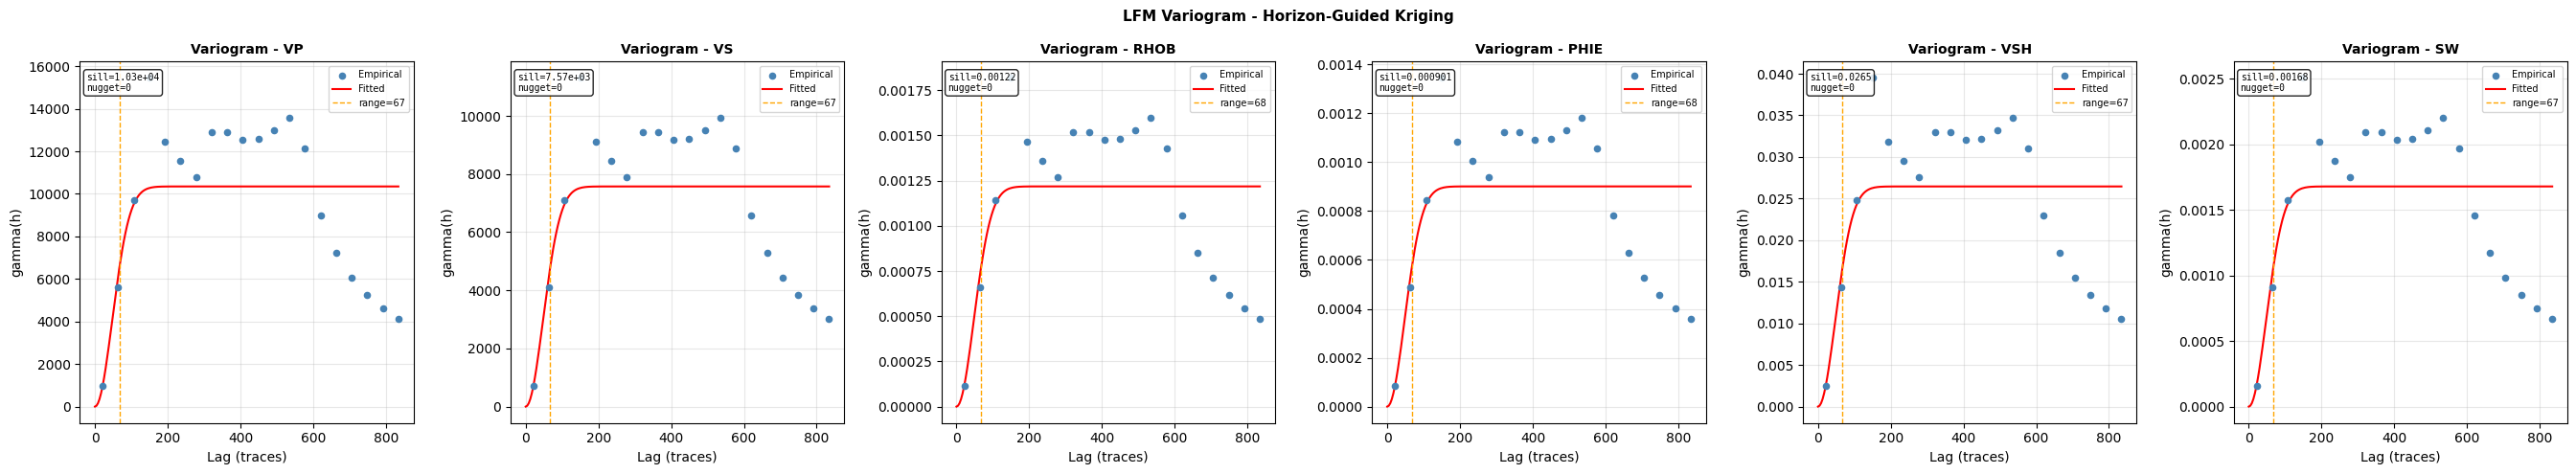

In [19]:
n_logs = len(VARIO_PARAMS)
fig, axes = plt.subplots(1, max(1,n_logs), figsize=(4.5*max(1,n_logs), 5))
if n_logs == 1: axes = [axes]

for ax, (log, vp) in zip(axes, VARIO_PARAMS.items()):
    lag_c = vp.get("lag_c", [])
    lag_g = vp.get("lag_g", [])
    if len(lag_c): ax.scatter(lag_c, lag_g, s=20, color="steelblue", zorder=3, label="Empirical")
    h_fit = np.linspace(0, max(lag_c.max() if len(lag_c) else 1, vp["range"]*1.5), 200)
    vfunc = VARIO_FUNCS.get(vp.get("model","spherical"), _vario_spherical)
    ax.plot(h_fit, vfunc(h_fit,vp["nugget"],vp["sill"],vp["range"]), "r-", lw=1.5, label="Fitted")
    ax.axvline(vp["range"], color="orange", lw=1., ls="--", label=f"range={vp['range']:.0f}")
    ax.set_xlabel("Lag (traces)"); ax.set_ylabel("gamma(h)")
    ax.set_title(f"Variogram - {log}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    stat_txt = f"sill={vp['sill']:.3g}\nnugget={vp['nugget']:.3g}"
    ax.text(0.02,0.97, stat_txt, transform=ax.transAxes, fontsize=7, va="top",
            family="monospace", bbox=dict(boxstyle="round,pad=0.3",fc="white",alpha=0.85))

plt.suptitle("LFM Variogram - Horizon-Guided Kriging", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## Cell 9 — QC: LFM section plots

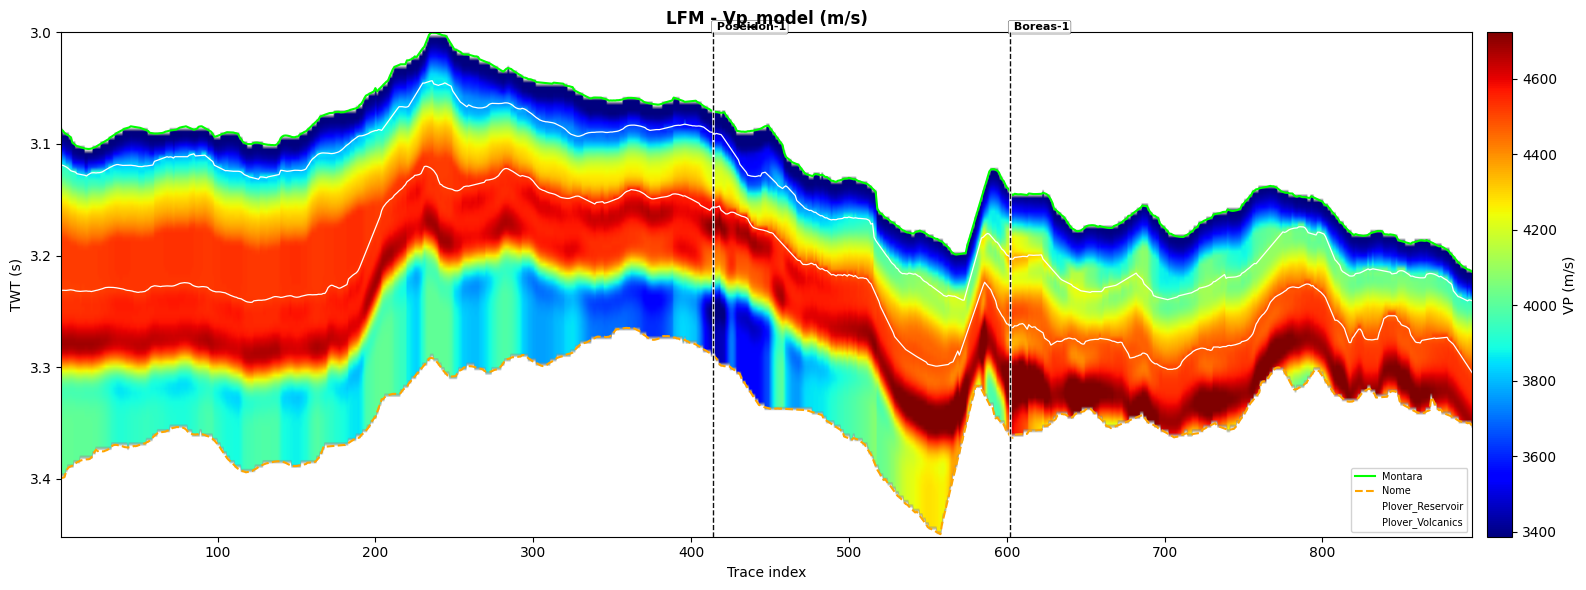

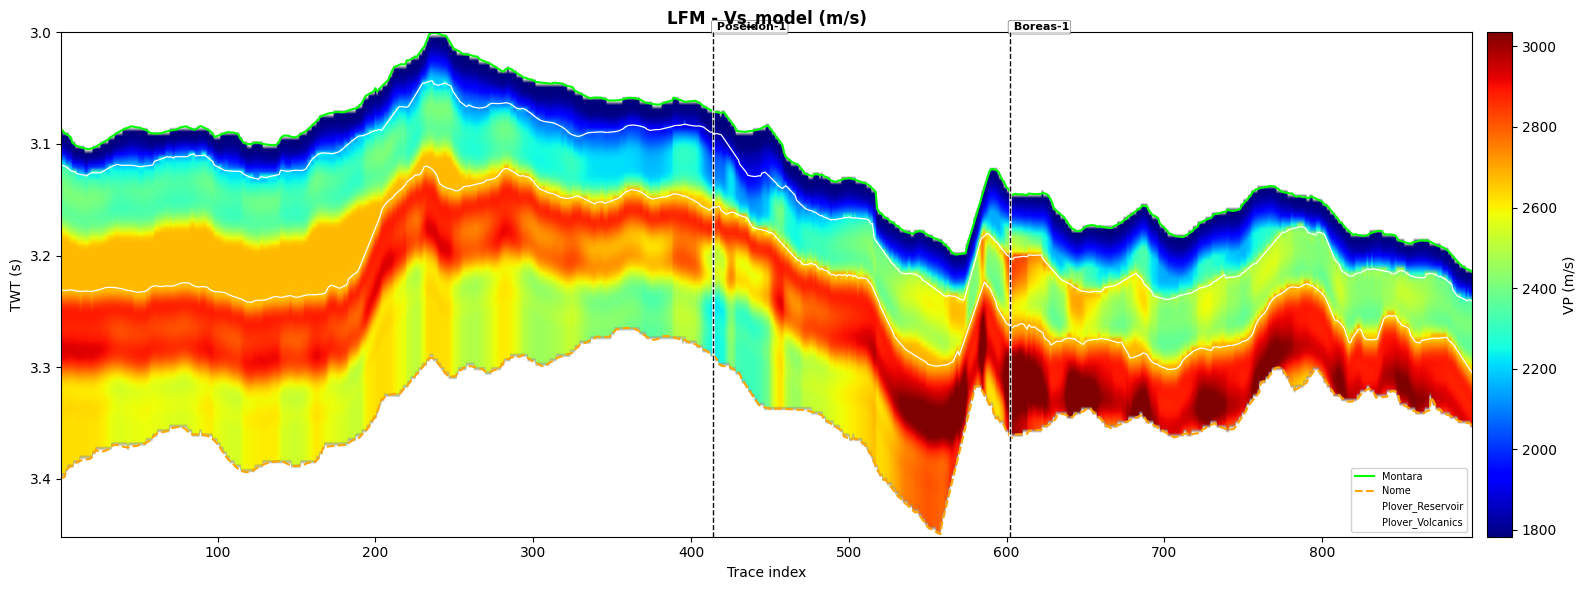

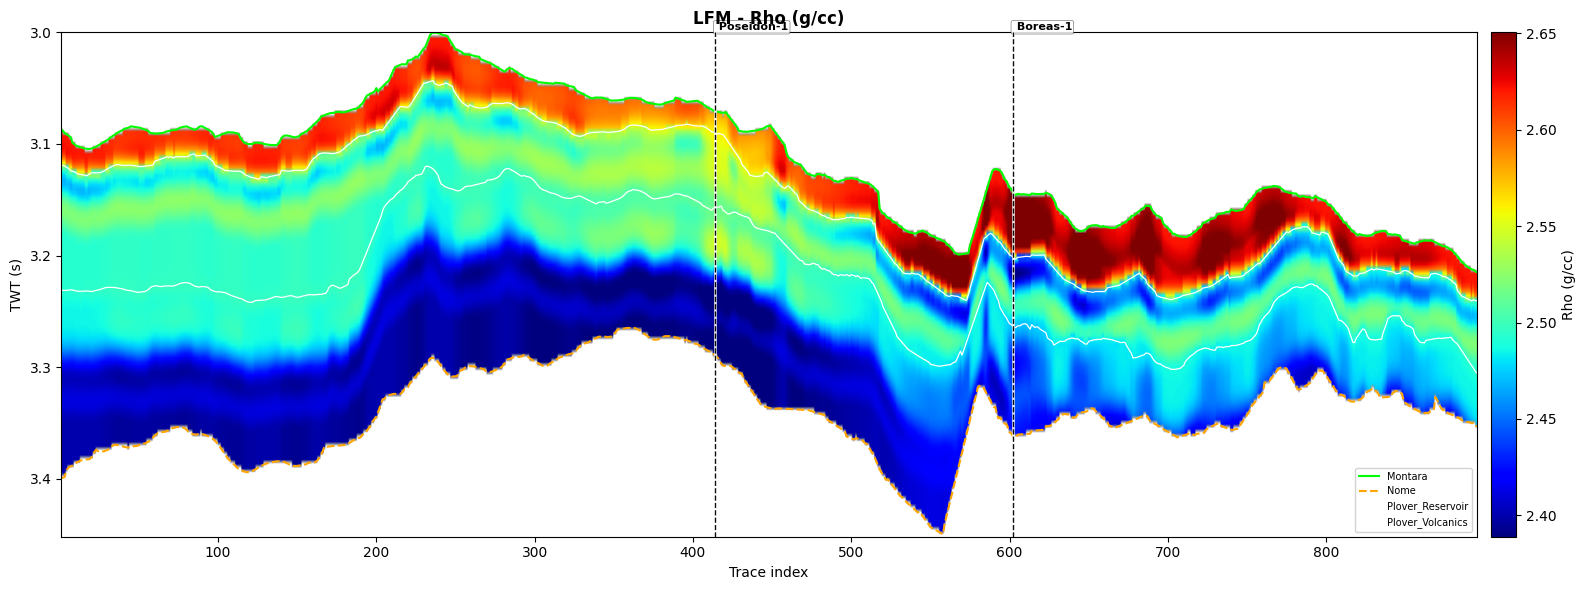

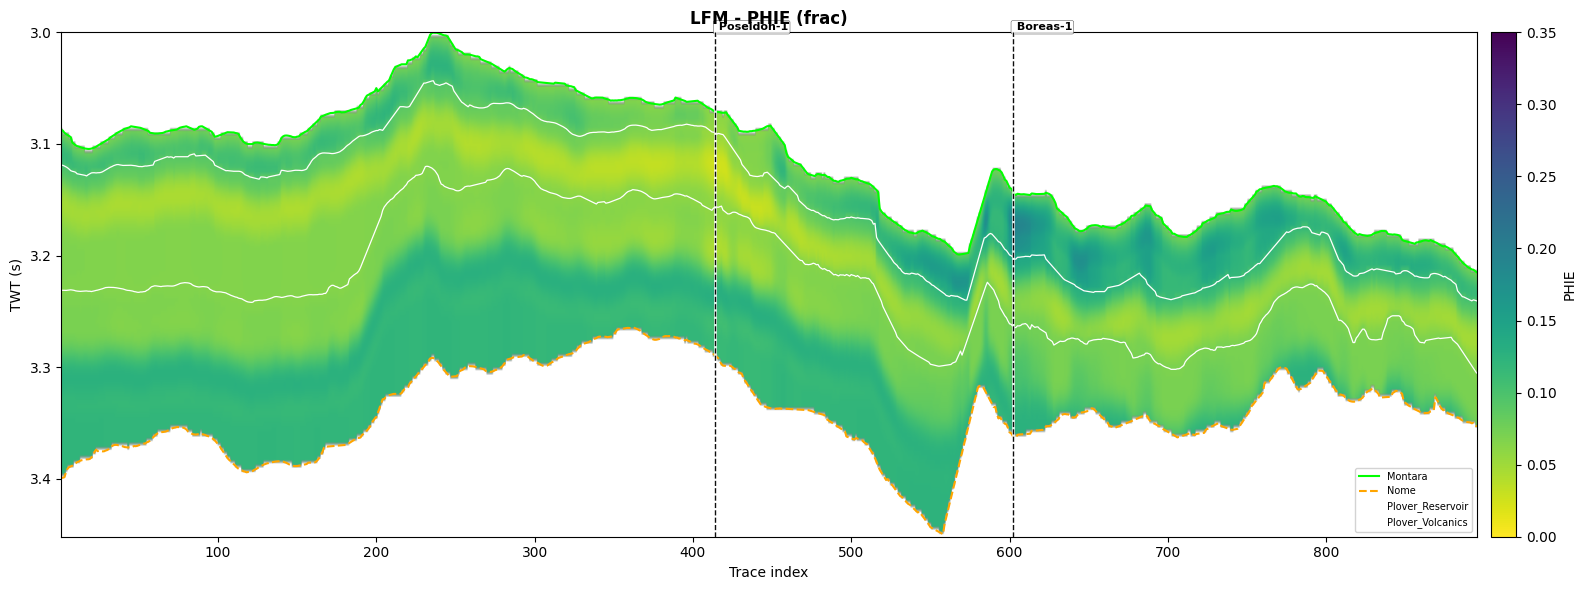

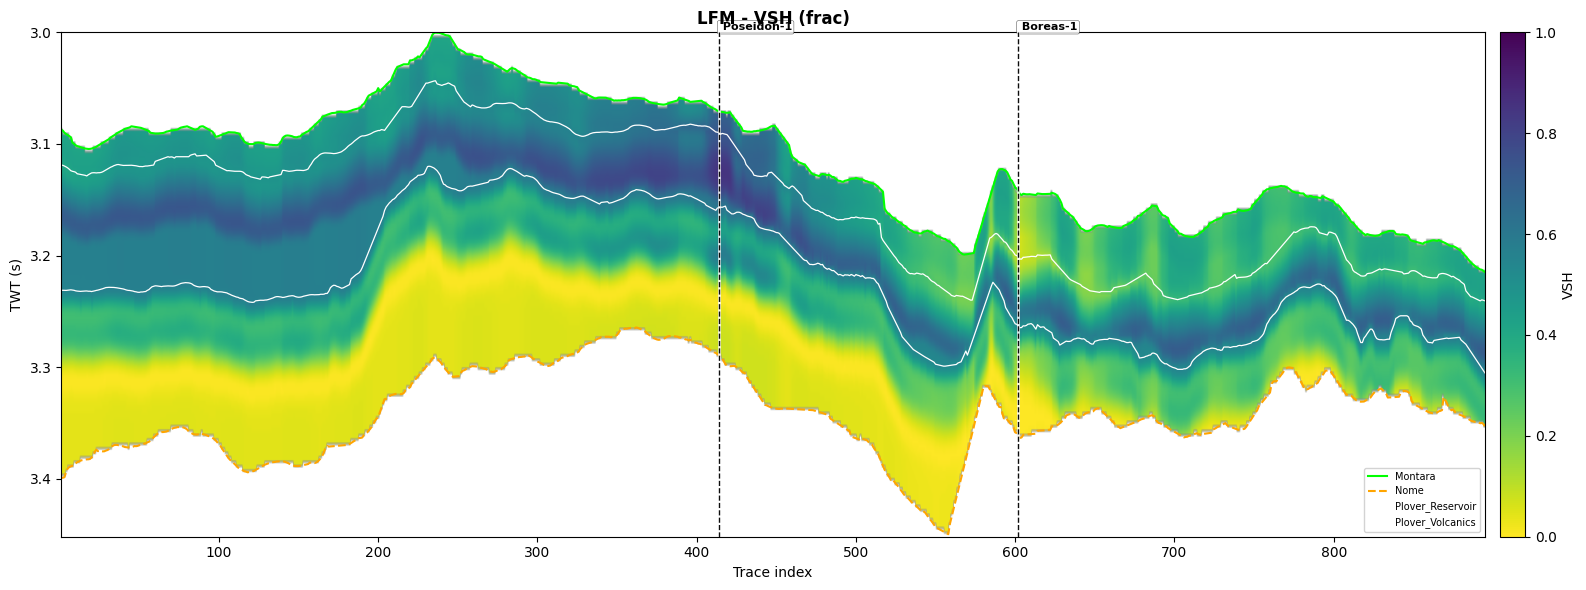

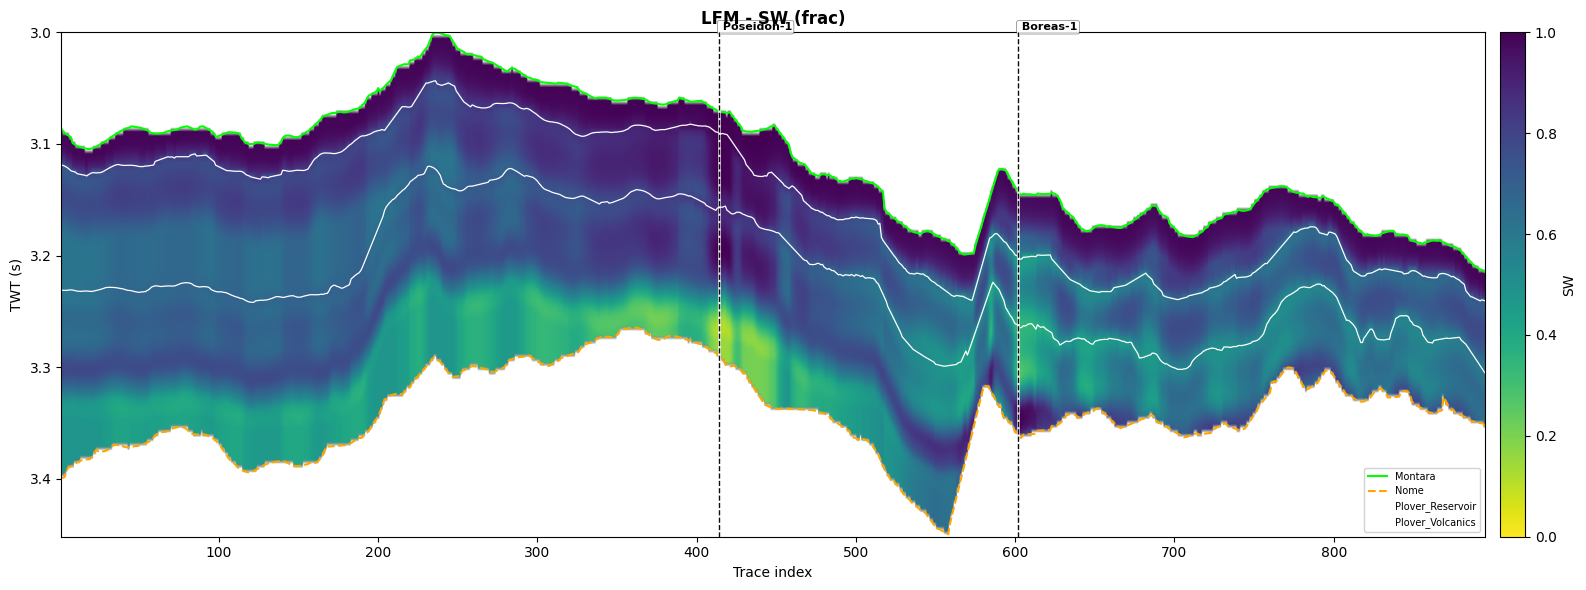

In [20]:
hor_styles = {k: CFG["horizon"]["STYLES"].get(k, {"color":"white","lw":0.9,"ls":"-"})
              for k in horizons.keys()}
well_markers = {wid: int(well_trace_idx[wid]) for wid in well_names}

if "VP" in LFM_CROP:
    v = LFM_CROP["VP"]
    vmin, vmax = float(np.nanpercentile(v, 2)), float(np.nanpercentile(v, 98))
    plot_utils.plot_inversion_section(
        v, twt_win, trace_axis_inv, title="LFM - Vp_model (m/s)", cbar_label="VP (m/s)",
        horizons=horizons, horizon_styles=hor_styles, well_traces=well_markers,
        cmap="jet", vmin=vmin, vmax=vmax)
    
if "VS" in LFM_CROP:
    v = LFM_CROP["VS"]
    vmin, vmax = float(np.nanpercentile(v, 2)), float(np.nanpercentile(v, 98))
    plot_utils.plot_inversion_section(
        v, twt_win, trace_axis_inv, title="LFM - Vs_model (m/s)", cbar_label="VP (m/s)",
        horizons=horizons, horizon_styles=hor_styles, well_traces=well_markers,
        cmap="jet", vmin=vmin, vmax=vmax)
    
if "RHOB" in LFM_CROP:
    v = LFM_CROP["RHOB"]
    vmin, vmax = float(np.nanpercentile(v, 2)), float(np.nanpercentile(v, 98))
    plot_utils.plot_inversion_section(
        v, twt_win, trace_axis_inv, title="LFM - Rho (g/cc)", cbar_label="Rho (g/cc)",
        horizons=horizons, horizon_styles=hor_styles, well_traces=well_markers,
        cmap="jet", vmin=vmin, vmax=vmax)

if "PHIE" in LFM_PETRO_CROP:
    plot_utils.plot_inversion_section(
        LFM_PETRO_CROP["PHIE"], twt_win, trace_axis_inv,
        title="LFM - PHIE (frac)", cbar_label="PHIE",
        horizons=horizons, horizon_styles=hor_styles, well_traces=well_markers,
        cmap="viridis_r", vmin=0.0, vmax=0.35)

if "VSH" in LFM_PETRO_CROP:
    plot_utils.plot_inversion_section(
        LFM_PETRO_CROP["VSH"], twt_win, trace_axis_inv,
        title="LFM - VSH (frac)", cbar_label="VSH",
        horizons=horizons, horizon_styles=hor_styles, well_traces=well_markers,
        cmap="viridis_r", vmin=0.0, vmax=1.0)

if "SW" in LFM_PETRO_CROP:
    plot_utils.plot_inversion_section(
        LFM_PETRO_CROP["SW"], twt_win, trace_axis_inv,
        title="LFM - SW (frac)", cbar_label="SW",
        horizons=horizons, horizon_styles=hor_styles, well_traces=well_markers,
        cmap="viridis_r", vmin=0.0, vmax=1.0)

## Cell 10 — QC: LFM vs well validation


  LFM vs WELL VALIDATION


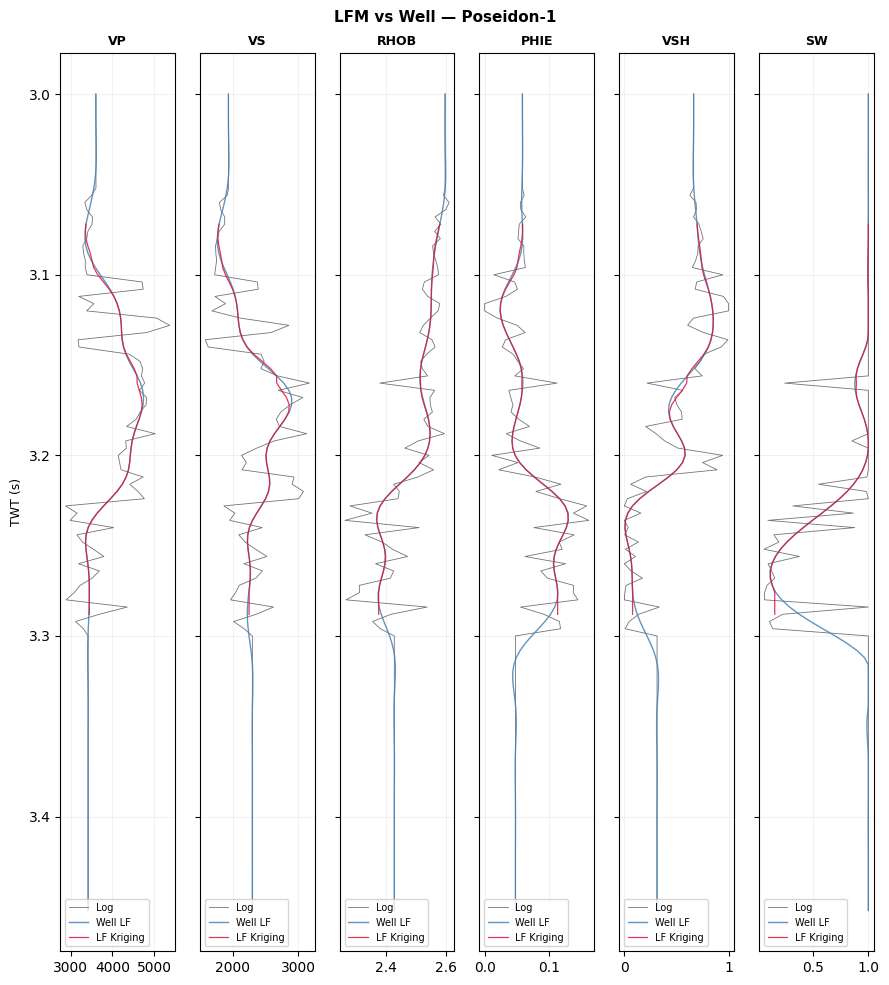

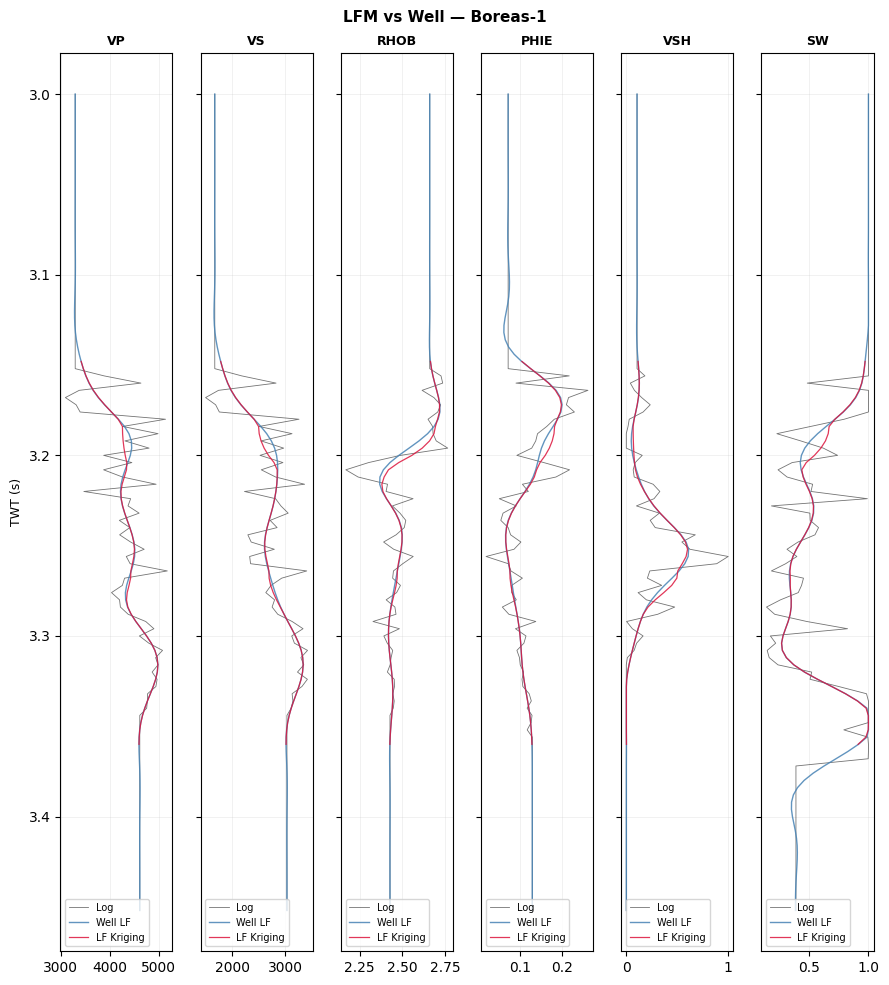

In [21]:
print("\n" + "=" * 72)
print("  LFM vs WELL VALIDATION")
print("=" * 72)

EL_MAP = {"VP": "VP", "VS": "VS", "RHOB": "RHOB"}

for wname in well_names:
    itr       = well_trace_idx[wname]
    wt        = well_twt[wname]
    all_cubes = {**LFM_CROP, **LFM_PETRO_CROP}
    n_cubes   = len(all_cubes)

    fig, axes = plt.subplots(
        1, max(1, n_cubes),
        figsize=(1.5 * max(1, n_cubes), 10),
        sharey=True
    )
    axes = list(axes) if hasattr(axes, "__iter__") else [axes]

    for ax, (key, cube) in zip(axes, all_cubes.items()):
        lfm_tr = cube[itr, :]

        # Tentukan kolom log asli dan LF yang sesuai dengan cube ini
        orig_col = None
        lf_col   = None
        for k in ["VP", "VS", "RHOB", "PHIE", "VSH", "SW"]:
            if key == EL_MAP.get(k, k) or key == k:
                if k in wt.columns:
                    orig_col = k
                if f"{k}_LF" in wt.columns:
                    lf_col = f"{k}_LF"
                break

        # 1) Log asli — hitam, tipis
        if orig_col is not None:
            ax.plot(wt[orig_col].values, twt_win,
                    color="black", lw=0.6, alpha=0.55, label="Log")

        # 2) Well LF — biru
        if lf_col is not None:
            ax.plot(wt[lf_col].values, twt_win,
                    color="steelblue", lw=1.0, alpha=0.85, label="Well LF")

        # 3) LF Kriging — merah
        ax.plot(lfm_tr, twt_win,
                color="crimson", lw=0.9, alpha=0.85, label="LF Kriging")

        ax.set_title(key, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7, loc="lower left")
        ax.grid(True, alpha=0.3, lw=0.4)
        if ax is axes[0]:
            ax.set_ylabel("TWT (s)", fontsize=9)

    axes[0].invert_yaxis()
    fig.suptitle(f"LFM vs Well — {wname}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Cell 11 — Save outputs untuk NB6

In [22]:
io_out = PipelineIO(stage="05_lfm")

# P1 KEY FIX: save dengan key konsisten (Vp_model, Vs_model, rho_sat)
io_out.save_npz("LFM",           **{k: v.astype(np.float32) for k,v in LFM.items()})
io_out.save_npz("LFM_PETRO",     **{k: v.astype(np.float32) for k,v in LFM_PETRO.items()})
io_out.save_npz("LFM_CROP",      **{k: v.astype(np.float32) for k,v in LFM_CROP.items()})
io_out.save_npz("LFM_PETRO_CROP",**{k: v.astype(np.float32) for k,v in LFM_PETRO_CROP.items()})

# BUG FIX: save_npy -> save_npz
io_out.save_npz("top_hz", top_hz=top_hz.astype(np.float64))
io_out.save_npz("bot_hz", bot_hz=bot_hz.astype(np.float64))

io_out.save_pkl("well_twt",       well_twt)
io_out.save_pkl("well_trace_idx", well_trace_idx)
io_out.save_pkl("WELLS_LITHO",    WELLS_LITHO)

io_out.save_json("lfm_meta", {
    "interpolation_method": "horizon_guided_ordinary_kriging",
    "n_wells":        len(well_twt),
    "wells":          list(well_twt.keys()),
    "n_pseudo_wells": N_PSEUDO,
    "range_traces_forced": int(KRIGING_CFG["range_traces"]),
    "inter_well_dist": float(inter_well_dist),
    "filter_freq_hz": float(LFM_CFG["filter_freq_hz"]),
    "LFM_keys":       list(LFM.keys()),
    "LFM_PETRO_keys": list(LFM_PETRO.keys()),
    "NTR":  int(NTR), "NT_WIN": int(NT_WIN), "DT_SEIS": float(DT_SEIS),
    "well_trace_idx": {w: int(i) for w,i in well_trace_idx.items()},
})

io_out.list_files()
print("\n" + "=" * 72)
print("  NB5 selesai")
print(f"  LFM keys  : {list(LFM.keys())}  [P1 fix: konsisten dgn NB6]")
print(f"  Pseudo-wells: N={N_PSEUDO}  range_forced={KRIGING_CFG['range_traces']} traces")
print("=" * 72)


  [05_lfm] 10 file(s) di pipeline_data\05_lfm:
    • bot_hz.npz                                     5.7 KB
    • LFM.npz                                      463.5 KB
    • LFM_CROP.npz                                 456.6 KB
    • lfm_meta.json                                  0.5 KB
    • LFM_PETRO.npz                                492.9 KB
    • LFM_PETRO_CROP.npz                           485.6 KB
    • top_hz.npz                                     5.7 KB
    • well_trace_idx.pkl                             0.0 KB
    • well_twt.pkl                                  26.6 KB
    • WELLS_LITHO.pkl                              292.5 KB

  NB5 selesai
  LFM keys  : ['VP', 'VS', 'RHOB']  [P1 fix: konsisten dgn NB6]
  Pseudo-wells: N=26  range_forced=94 traces
